Theory : [youtube video](https://youtu.be/Q8l0Vip5YUw?si=n4dwH9kBPrQQKZ8_)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [2]:
import pandas as pd
df = pd.read_csv(path + "/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [4]:
target = df.Survived
inputs = df.drop('Survived',axis='columns')

In [5]:
inputs.head()

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [6]:
dummies = pd.get_dummies(df.Sex, dtype=int)
dummies.head()

,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1


In [7]:
inputs = pd.concat([inputs,dummies],axis='columns')
inputs.head()

,Pclass,Sex,Age,Fare,female,male
0,3,male,22.0,7.2500,0,1
1,1,female,38.0,71.2833,1,0
2,3,female,26.0,7.9250,1,0
3,1,female,35.0,53.1000,1,0
4,3,male,35.0,8.0500,0,1


In [9]:
inputs = inputs.drop('Sex', axis='columns')
inputs.head()

,Pclass,Age,Fare,female,male
0,3,22.0,7.2500,0,1
1,1,38.0,71.2833,1,0
2,3,26.0,7.9250,1,0
3,1,35.0,53.1000,1,0
4,3,35.0,8.0500,0,1


In [11]:
inputs.isnull().sum()

,0
Pclass,0
Age,177
Fare,0
female,0
male,0


In [12]:
inputs.Age = inputs.Age.fillna(inputs.Age.mean())
inputs.isnull().sum()

,0
Pclass,0
Age,0
Fare,0
female,0
male,0


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.2)

Normal Distribution (বা Gaussian Distribution) হলো এমন একটি probability distribution যেখানে অধিকাংশ data মাঝখানে (mean-এর কাছাকাছি) থাকে এবং দুই পাশে সমানভাবে কমতে থাকে। এর গ্রাফটি ঘণ্টার মতো দেখতে, তাই একে Bell Curve বলা হয়।

এটি দেখতে কেমন?
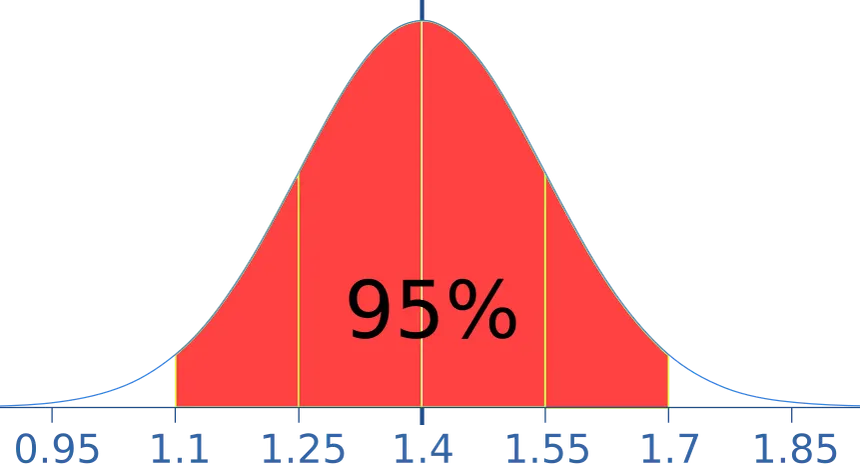

মাঝখানে সবচেয়ে বেশি data থাকে।
বাম ও ডান পাশে data ধীরে ধীরে কমে।
দুই পাশ একে অপরের mirror image।
বৈশিষ্ট্য
Mean = Median = Mode
তিনটিই একই স্থানে থাকে (মাঝখানে)।
Symmetric (সমমিত)
Mean-এর বাম ও ডান পাশ একই রকম।
Bell-shaped Curve
ঘণ্টার মতো আকৃতি।
68-95-99.7 Rule

Normal distribution-এর একটি গুরুত্বপূর্ণ নিয়ম হলো:

68% data থাকে Mean ± 1 Standard Deviation (σ) এর মধ্যে।
95% data থাকে Mean ± 2σ এর মধ্যে।
99.7% data থাকে Mean ± 3σ এর মধ্যে।

এটি বোঝার জন্য:

        68%
     <-------->

     95%
<------------------>

    99.7%
<-------------------------->
উদাহরণ

ধরো একটি পরীক্ষায়:

Mean = 70
Standard Deviation = 10

তাহলে:

68% শিক্ষার্থীর নম্বর হবে 60–80
95% শিক্ষার্থীর নম্বর হবে 50–90
99.7% শিক্ষার্থীর নম্বর হবে 40–100
Machine Learning-এ কেন গুরুত্বপূর্ণ?

অনেক ML algorithm ধরে নেয় যে data প্রায় normal distribution অনুসরণ করে।

যেমন:

Linear Regression-এর কিছু assumption
Gaussian Naive Bayes
Z-score Normalization
Statistical Hypothesis Testing
Confidence Interval
কখন Data Normal Distribution অনুসরণ করে?

অনেক বাস্তব ডেটা প্রায় normal distribution-এর মতো হয়, যেমন:

মানুষের উচ্চতা
IQ score
Measurement error
কিছু পরীক্ষার নম্বর
Blood pressure (অনেক population-এ)

তবে সব data normal হয় না। উদাহরণস্বরূপ:

মানুষের আয় (Income)
বাড়ির দাম
ওয়েবসাইট ট্রাফিক

এগুলো প্রায়ই skewed distribution অনুসরণ করে।

In [16]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

In [17]:
model.fit(X_train,y_train)

GaussianNB()

In [18]:
model.score(X_test,y_test)

0.7597765363128491

In [19]:
X_test[0:10]

,Pclass,Age,Fare,female,male
619,2,26.000000,10.5000,0,1
335,3,29.699118,7.8958,0,1
169,3,28.000000,56.4958,0,1
717,2,27.000000,10.5000,1,0
616,3,34.000000,14.4000,0,1
161,2,40.000000,15.7500,1,0
623,3,21.000000,7.8542,0,1
701,1,35.000000,26.2875,0,1
774,2,54.000000,23.0000,1,0
858,3,24.000000,19.2583,1,0


In [20]:
y_test[0:10]

,Survived
619,0
335,0
169,0
717,1
616,0
161,1
623,0
701,1
774,1
858,1


In [21]:
model.predict(X_test[0:10])

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1])

Dataset : [spam dataset](https://github.com/codebasics/py/blob/master/ML/14_naive_bayes/spam.csv)

In [22]:
mail_df = pd.read_csv('/content/spam.csv')
mail_df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
mail_df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [24]:
mail_df['Spam'] = mail_df['Category'].apply(lambda x: 1 if x=='spam' else 0)
mail_df.head()

,Category,Message,Spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(mail_df.Message,mail_df.Spam,test_size=0.25)

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer()
X_train_count = v.fit_transform(X_train.values)
X_train_count.toarray()[:2]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

Multinomial Naive Bayes হলো Naive Bayes-এর একটি ধরন, যা count data বা frequency data-এর জন্য ব্যবহৃত হয়। এটি সবচেয়ে বেশি ব্যবহৃত হয় text classification-এ, যেমন:

Spam Detection

Sentiment Analysis

News Classification

Document Classification


এটিও

P(A∣B) = P(B∣A)P(A)/P(B)
	​


ব্যবহার করে probability গণনা করে, তবে এখানে feature-এর value হিসেবে শব্দ কতবার এসেছে (count/frequency) সেটি গুরুত্বপূর্ণ।

সাধারণ Naive Bayes বনাম Multinomial Naive Bayes

ধরো তোমার কাছে দুটি email আছে।

Email 1 (Spam)

Free Free Free Win Money

Email 2 (Not Spam)

Meeting Tomorrow Office

সাধারণ Naive Bayes শুধু দেখবে:

Free আছে? ✔


Money আছে? ✔

Meeting আছে? ✘

কিন্তু Multinomial Naive Bayes দেখবে:

Free = 3 বার

Win = 1 বার

Money = 1 বার

অর্থাৎ শব্দ কতবার এসেছে, সেটিও হিসাবের মধ্যে নেয়।

কেন "Multinomial"?

কারণ এখানে feature-এর মান হতে পারে:

Free = 5

Money = 2

Offer = 8

অর্থাৎ feature-এর মান 0, 1, 2, 3, ... যেকোনো non-negative integer হতে পারে।

একটি উদাহরণ

Training Data

Email	Class

free free win money	Spam

free offer win	Spam

meeting office project	Ham

office project tomorrow	Ham

Training-এর সময়

Spam class-এ শব্দের সংখ্যা:

free = 3

win = 2

money = 1

offer = 1

Ham class-এ:

meeting = 1

office = 2

project = 2

tomorrow = 1

নতুন Email

free free money

এখন Multinomial NB হিসাব করবে:

Spam document-এ free কতবার দেখা গেছে?

Spam document-এ money কতবার দেখা গেছে?

তারপর probability বের করবে।

যেহেতু free এবং money Spam-এ অনেক বেশি দেখা গেছে, তাই Spam-এর probability বেশি হবে।

Prediction:

Spam

Bag of Words Representation

Multinomial NB সাধারণত Bag of Words বা Count Vectorizer ব্যবহার করে।

ধরো vocabulary:

["free", "money", "meeting", "office"]

Email:

free free office

Vector হবে:

free	money	meeting	office

2	0	0	1

এখানে 2 মানে "free" দুইবার এসেছে।

Formula (ধারণা)

প্রতিটি class-এর জন্য:

P(Class)×P(word
1
	​

∣Class)
count
1
	​

×P(word
2
	​

∣Class)
count
2
	​

×⋯

অর্থাৎ, কোনো শব্দ যতবার আসে, তার probability ততবার গণনায় প্রভাব ফেলে।

কোথায় ব্যবহার হয়?

সবচেয়ে বেশি ব্যবহৃত হয়:

Email Spam Detection

SMS Spam Detection

Sentiment Analysis

Fake News Detection

News Classification

Language Identification

Gaussian vs Multinomial Naive Bayes

Gaussian NB	Multinomial NB

Continuous data-এর জন্য -	Count/Frequency data-এর জন্য

ধরে নেয় data Normal Distribution অনুসরণ করে	- ধরে নেয় feature হলো word counts বা frequency

উদাহরণ: Height, Weight, Age	উদাহরণ: শব্দ কতবার এসেছে

In [27]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_count,y_train)

MultinomialNB()

In [28]:
emails = [
    'Hey mohan, can we get together to watch footbal game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]
emails_count = v.transform(emails)
model.predict(emails_count)

array([0, 1])

In [29]:
X_test_count = v.transform(X_test)
model.score(X_test_count, y_test)

0.9856424982053122

In [30]:
from sklearn.pipeline import Pipeline
clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

In [31]:
clf.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [32]:
clf.score(X_test,y_test)

0.9856424982053122